### [ 이미지/ 영상 연산 ] <hr>

- 픽셀 단위 연산
- 픽셀 값 범위 0~255-> 부호없는 8비트 uint8


In [ ]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import cv_utils



In [ ]:
## ------------------------------------------
## 이미지 연산=> 밝기 조절. 0에 가까운 값- 어둡게, 255에 가까운 값- 밝게
## ------------------------------------------

img1= '../Images/man_face.jpg'
img2= '../Images/lion_face.jpg'

img1= cv2.imread(img1)
img2= cv2.imread(img2)


## 두 이미지 크기 맞추기
# img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
win_name = "Lion Face Alpha Control"
cv2.namedWindow(win_name)

## 트랙바 생성
## 0   -> 사람 얼굴만 보임
## 100 -> 라이언 얼굴만 보임
cv2.createTrackbar("Lion", win_name, 50, 100, lambda x: None)

while True:
    ## 트랙바 값 읽기
    lion_value = cv2.getTrackbarPos("Lion", win_name)

    ## 0~100 값을 0.0~1.0으로 변환
    alpha = lion_value / 100

    ## 이미지 합성
    ## img1 비율: 1 - alpha
    ## img2 비율: alpha
    result = cv2.addWeighted(img1, 1 - alpha, img2, alpha, 0)
    cv2.imshow(win_name, result)
    key = cv2.waitKey(30) & 0xFF

    ## ESC 또는 x 누르면 종료
    if key == 27 or key == ord('x'):
        break

    ## s 누르면 저장
    if key == ord('s'):
        cv2.imwrite("lion_face_blend_result.jpg", result)
        print("저장 완료: lion_face_blend_result.jpg")

cv2.destroyAllWindows()


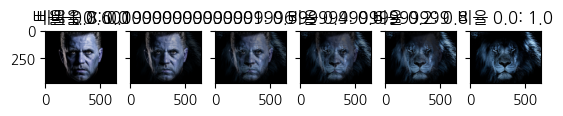

In [9]:
# ---------------------------------------------
# 이미지 합성: 단계별 과정 출력
# ---------------------------------------------

weight= np.linspace(0,1,6)[::-1]

wNP= []
for w in weight:
    wNP.append(cv2.addWeighted(img1, w, img2, 1-w, 0))

wNP= [cv2.addWeighted(img1, w, img2, 1-w, 0) for w in weight]
title= [f'비율 {w}: {1-w}' for w in weight]

cv_utils.printPlots(1, 6, title, wNP)

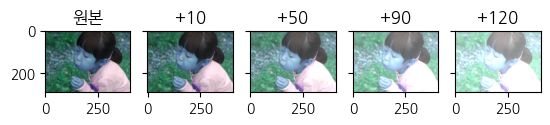

In [ ]:
## ------------------------------------
## 덧셈& 뺄셈 연산
## ------------------------------------
## 덧셈=> 밝게
addNPs= [testNP + value for value in range(10, 131, 40)]
titles= [f'+{value}' for value in range(10, 131, 40)]

for arr in addNPs:
    arr[arr>255]= 255

cv_utils.printPlots(1, 5, ['원본', '+10', '+50', '+90', '+120'], [imgNP]+ addNPs)